# Demonstration of Parameter estimation with `nessai` + `pygwtf` (TaylorT3, AET, sky-position)

The purpose of this notebook is to demonstrate roughly how one would perform parameter estimation using the waveforms generated from this library. We will use `nessai` for this, however this choice is motivated only by the fact that this sampler allows for batched likelihoods, in principle any sampler can be used. 

Inject a chirping stellar-origin BBH at $f_0 = 10\,\mathrm{mHz}$ into a 4-year LISA observation, project it onto the **TDI-2 AET channels**, weight by an analytic **Sangria** PSD from `lisa-data-challenge`, and recover the parameters with `nessai`. Time to coalescence at this frequency is $\sim 70\,\mathrm{yr}$, so the signal still safely stays in band for the whole mission.

What this notebook does:

1. **Waveform model:** `TaylorT3Spin` with $s_1 = s_2 = 0$ (so it reduces to the non-eccentric, non-spinning 3.5PN waveform).
2. **Channels:** TDI-2 $\{A, E, T\}$ -- so sky position and polarisation actually matter and can be inferred.
3. **Sampling parameters:** $(\mathcal{M}_c, \eta, \cos\iota, D, f_0, \phi_\mathrm{coal}, \psi, \lambda, \beta)$ -- chirp mass instead of total mass, plus polarisation and ecliptic longitude/latitude. $s_1$, $s_2$ are held fixed at the truth.
4. **Likelihood:** the *full* Gaussian likelihood $-\tfrac{1}{2}\langle d-h|d-h\rangle = \Re\langle d|h\rangle - \tfrac{1}{2}\langle h|h\rangle - \tfrac{1}{2}\langle d|d\rangle$, with $\langle d|d\rangle$ pre-computed once.
5. **PSD:** Sangria analytic noise via `ldc.lisa.noise.get_noise_model`, evaluated per AET channel and tiled across SFT segments (assumed stationary).
6. **Diagnostic:** before nessai is launched we plot 1-D log-likelihood slices through the chirp mass to confirm the likelihood is unimodal, peaked at the truth, and behaves smoothly.

In [15]:
import os
import shutil

import corner
import matplotlib.pyplot as plt
import numpy as np

from ldc.lisa.noise import get_noise_model

from nessai.flowsampler import FlowSampler
from nessai.livepoint import parameters_to_live_point
from nessai.model import Model
from nessai.utils.logging import configure_logger

from pygwtf.generator import AnalyticTimeFrequencyWaveform
from pygwtf.models import TaylorT3Spin

# ----------------------------------------------------------------------------
# Backend switch. Set `use_GPU = True` to run the generator with CuPy + numba
# CUDA kernels. Requires `cupy` and a CUDA-capable GPU. All arrays handed to
# the generator (data, psds, parameters_response, parameter dicts) must live
# on the GPU; results are pulled back to numpy via backend.asnumpy() at the
# nessai / matplotlib boundaries.
# ----------------------------------------------------------------------------
use_GPU = False

if use_GPU:
    import cupy as cp
    xp = cp
else:
    xp = np

## 1. Time-frequency grid

We select a very long time-segment of 1-day here as we are aiming for this analysis to run somewhat quickly on a CPU, on a local machine as a demonstration. In real analysis/search usually 3-6 hour time-segments are considered, with a cadence of time-series observations of 5s, in order to recover the high frequency part of the LISA spectrum. 

Daily SFT cadence over 4 years, $f_{\rm{\max}} = 20\,\mathrm{mHz}$ -- comfortable headroom over $f_0 = 10\,\mathrm{mHz}$.

In [16]:
dT = 86400.0           # 1 day SFT length (Should really be lower for robust analysis, but we want something cheap ])
nT = 365 * 4           # 4 year mission
dt = 25.0              # f_max = 1/(2 dt) = 20 mHz
dF = 1.0 / dT
fmax = 1.0 / (2 * dt)
nF = int(fmax / dF) + 1

config = {
    "dT": dT,
    "nT": nT,
    "dt": dt,
    "dF": dF,
    "nF": nF,
    "kernel_width": 10,
}
print(f"nT = {nT}, nF = {nF}, dF = {dF:.3e} Hz, f_max = {fmax:.3f} Hz")

nT = 1460, nF = 1729, dF = 1.157e-05 Hz, f_max = 0.020 Hz


## 2. TDI-2 generator

`tdi_type=2` projects the waveform onto the AET TDI-2 combinations. Spacecraft orbits and light-travel-times are computed from analytic LISA orbits, but there are functions in the library to read in (appropriately) packaged up data from the LISA-data-challenge ```Mojito-Light```

# GPU PE Note

Note that if you are performing PE with a small batch of likelihoods, as is common for MCMC-like samplers, it may be beneficial to instead use the ```gpu_kernel_blocked``` kernel, this maximises occupancy of the GPU for small batch sizes by distributing threads across individual frequency points. You can turn this on with the argument ```block_vectorised_gpu = True``` in the generator.

In [17]:
generator = AnalyticTimeFrequencyWaveform(
    model_class=TaylorT3Spin,
    config=config,
    tdi_type=2,
    backend="gpu" if use_GPU else "cpu",
)
generator.model.parameters

Spacecraft orbits not supplied. Falling back to analytic orbits
Spacecraft light travel times not supplied. Falling back to analytic calculation


['M', 'eta', 'cosi', 'D', 'f0', 's1', 's2', 'phi_coal']

## 3. Injection

Set $s_1 = s_2 = 0$ -- the model still expects them in the parameter dict but they are pinned to zero in the likelihood. Polarisation, ecliptic longitude and ecliptic latitude are passed through the `parameters_response` argument as $[\cos\iota, \psi, \lambda, \beta]$.

The chirp mass is $\mathcal{M}_c = M\,\eta^{3/5}$; we'll sample in $\mathcal{M}_c$ and transform back to $M$ inside the likelihood.

In [18]:
true_pars = {
    "M":        58.13,        # total mass [Msun] -- chosen so Mc ~ 25 Msun at eta=0.245
    "eta":      0.245,        # (0, 0.25)
    "cosi":     0.5,
    "D":        1.0e7,        # 10 Mpc
    "f0":       1.0e-2,       # 10 mHz -- chirps appreciably over 4 yr
    "s1":       0.0,
    "s2":       0.0,
    "phi_coal": 0.1,
}
true_pol    = np.pi / 6.0     # fixed polarisation
true_lambda = 5 * np.pi / 4.0 # ecliptic longitude
true_beta   = np.pi / 3.0     # ecliptic latitude
true_Mc     = true_pars["M"] * true_pars["eta"] ** (3.0 / 5.0)
print(f"true Mc = {true_Mc:.6f} Msun")

# Response array goes through the numba kernel as-is, so it must live on
# the chosen backend (cupy on GPU, numpy on CPU).
true_response = xp.asarray(
    [[true_pars["cosi"], true_pol, true_lambda, true_beta]], dtype=np.float64
)

tf_signal = generator(true_pars, parameters_response=true_response)
print("signal shape (nT, nF, n_channels=AET):", tf_signal.shape)

true Mc = 24.997696 Msun
signal shape (nT, nF, n_channels=AET): (1460, 1729, 3)


### Morphology -- spectrogram of the injected signal

The slow chirp shows up as a small monotonic frequency drift over the mission; the slow amplitude modulation along time is the LISA antenna pattern sweeping the source as the constellation orbits the Sun.

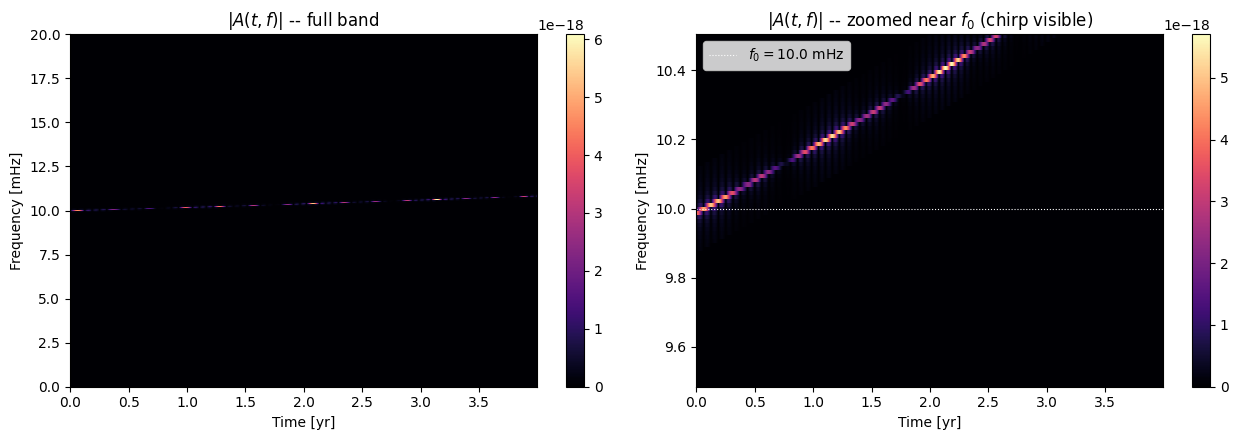

In [19]:
# Pull the generator's grid + waveform back to numpy for matplotlib.
asnumpy = generator.backend.asnumpy
t_yr = asnumpy(generator.t_tranche) / (365.25 * 24 * 3600.0)
f_mHz = asnumpy(generator.f_tranche) * 1e3
amp = np.abs(asnumpy(tf_signal[:, :, 0])).T

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) full-band view: where the signal sits in the time-frequency plane
im0 = axes[0].pcolormesh(t_yr, f_mHz, amp, shading="auto", cmap="magma")
axes[0].set_xlabel("Time [yr]")
axes[0].set_ylabel("Frequency [mHz]")
axes[0].set_title(r"$|A(t,f)|$ -- full band")
axes[0].set_ylim(0, fmax * 1e3)
fig.colorbar(im0, ax=axes[0])

# (b) zoom around f0 to see the chirp drift over 4 yr
i_lo = int(np.floor((true_pars["f0"] - 5e-4) / dF))
i_hi = int(np.ceil ((true_pars["f0"] + 5e-4) / dF))
im1 = axes[1].pcolormesh(
    t_yr, f_mHz[i_lo:i_hi], amp[i_lo:i_hi, :], shading="auto", cmap="magma"
)
axes[1].axhline(true_pars["f0"] * 1e3, color="white", ls=":", lw=0.8,
                label=fr"$f_0={true_pars['f0']*1e3:.1f}$ mHz")
axes[1].set_xlabel("Time [yr]")
axes[1].set_ylabel("Frequency [mHz]")
axes[1].set_title(r"$|A(t,f)|$ -- zoomed near $f_0$ (chirp visible)")
axes[1].legend(loc="upper left", framealpha=0.8)
fig.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

## 4. PSD from `lisa-data-challenge`

Use the analytic **Sangria** noise model. We evaluate it once on the SFT frequency grid (the noise is treated as stationary, so the PSD is tiled identically across all SFT segments). The $f=0$ bin is set to a non-zero value so that any tile the Fresnel kernel happens to touch there contributes essentially nothing.

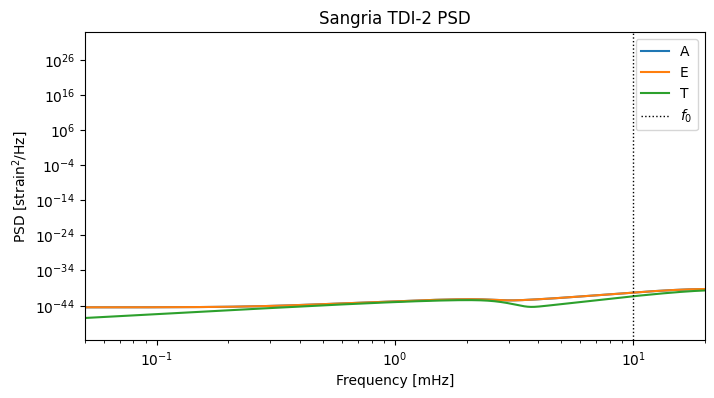

In [20]:
wd_years = nT * dT / (365.25 * 24 * 3600.0)
# LDC's noise model is CPU-only, so build the PSD in numpy.
f_grid = generator.backend.asnumpy(generator.f_tranche).copy()
f_grid[0] = f_grid[1]                         # avoid div-by-zero in LDC
noise = get_noise_model("sangria", f_grid, wd=wd_years)

psd_1d = np.stack(
    [noise.psd(f_grid, option=c, tdi2=True) for c in ("A", "E", "T")],
    axis=-1,
)  # shape (nF, 3)
psd_1d[0] = 1.0e30                            # neutralise DC bin

# Move the PSD + data onto the chosen backend (cupy when use_GPU=True).
psds = xp.asarray(np.broadcast_to(psd_1d[None, :, :], (nT, nF, 3)).copy())
data = tf_signal.astype(np.complex128)        # noise-free injection (xp-backed)

fig, ax = plt.subplots(figsize=(8, 4))
for i, c in enumerate("AET"):
    ax.loglog(f_grid * 1e3, psd_1d[:, i], label=c)
ax.axvline(true_pars["f0"] * 1e3, color="k", ls=":", lw=1, label=r"$f_0$")
ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel(r"PSD [strain$^2$/Hz]")
ax.set_title("Sangria TDI-2 PSD")
ax.set_xlim(0.05, fmax * 1e3)
ax.legend()
plt.show()

## 5. Inner products: SNR and $\langle d|d\rangle$

Two things at once: (i) sanity-check the matched-filter SNR via $\langle h|h\rangle$, and (ii) pre-compute $\langle d|d\rangle$ so we can build the *full* Gaussian likelihood $\log\mathcal{L} = \Re\langle d|h\rangle - \tfrac{1}{2}\langle h|h\rangle - \tfrac{1}{2}\langle d|d\rangle$ later. Since the injection is noise-free, $\langle d|d\rangle = \langle h_\mathrm{inj} | h_\mathrm{inj}\rangle$, which the kernel returns for us when called at the truth.

In [21]:
stat_true = generator(
    true_pars,
    channels=data,
    psds=psds,
    parameters_response=true_response,
    compute_statistic=True,
)  # shape (nT, 2): per-segment d_h, h_h
# float() pulls the 0-d sum back to the host whether stat_true is numpy or cupy.
d_h_inj = float(stat_true[:, 0].sum().real)
h_h_inj = float(stat_true[:, 1].sum().real)
dd = h_h_inj                                  # noise-free injection
snr = float(np.sqrt(h_h_inj))
print(f"<d|h>_inj = {d_h_inj:.3e}")
print(f"<h|h>_inj = {h_h_inj:.3e}")
print(f"<d|d>     = {dd:.3e}")
print(f"SNR       = {snr:.2f}")
print(f"log L(truth) = {d_h_inj - 0.5 * h_h_inj - 0.5 * dd:.3e}  (should be ~0)")

<d|h>_inj = 2.786e+04
<h|h>_inj = 2.786e+04
<d|d>     = 2.786e+04
SNR       = 166.91
log L(truth) = 0.000e+00  (should be ~0)


## 6. Vectorised likelihood

`pygwtf` evaluates many sources per kernel launch. `nessai`'s `Model.allow_vectorised=True` hands every live point in the current batch to `log_likelihood` as a single structured array, and we feed all of them through `compute_statistic=True` in one shot.

NOTE: If running this on a local CPU, there won't be a good use of batching over waveforms/sources, the batching is only done across GPU threads. In the CPU case it is a simple for loop over each source. 

Sampling parameters: $(\mathcal{M}_c, \eta, \cos\iota, D, f_0, \phi_\mathrm{coal}, \lambda, \beta)$. Total mass is recovered as $M = \mathcal{M}_c\,\eta^{-3/5}$; spins and polarisation are pinned to their injected values.

In [ ]:
class GWTFModel(Model):
    """nessai Model: vectorised log-likelihood through pygwtf.

    Lives on whichever backend (numpy / cupy) the supplied generator uses.
    Live points come in as numpy structured arrays from nessai, are pushed
    to the backend for the kernel call, and the resulting log-likelihoods
    are pulled back to numpy on return.
    """

    allow_vectorised = True

    def __init__(
        self,
        generator,
        data,
        psds,
        dd,
        prior_bounds,
        fixed_intrinsic,
    ):
        self.generator = generator
        self.data = data
        self.psds = psds
        self.dd = float(dd)
        self.fixed_intrinsic = fixed_intrinsic   # e.g. {"s1": 0, "s2": 0}
        self.names = list(prior_bounds.keys())
        self.bounds = {k: list(v) for k, v in prior_bounds.items()}
        self._log_prior_norm = -sum(
            np.log(hi - lo) for (lo, hi) in prior_bounds.values()
        )

    def log_prior(self, x):
        return np.log(self.in_bounds(x), dtype=float) + self._log_prior_norm

    def _pack(self, x):
        """structured live-point batch -> (intrinsic dict, response array).

        Arrays are built on `generator.backend.xp` so they land in the right
        memory space (host for CPU, device for GPU).
        """
        xp = self.generator.backend.xp
        n = x.shape[0]
        Mc   = xp.asarray(x["Mc"],   dtype=np.float64)
        eta  = xp.asarray(x["eta"],  dtype=np.float64)
        cosi = xp.asarray(x["cosi"], dtype=np.float64)
        D    = xp.asarray(x["D"],    dtype=np.float64)
        f0   = xp.asarray(x["f0"],   dtype=np.float64)
        phic = xp.asarray(x["phi_coal"], dtype=np.float64)
        psi  = xp.asarray(x["psi"], dtype=np.float64)
        lam  = xp.asarray(x["lambda_"], dtype=np.float64)
        bet  = xp.asarray(x["beta"], dtype=np.float64)
        M = Mc * eta ** (-3.0 / 5.0)

        pars = {
            "M":        M,
            "eta":      eta,
            "cosi":     cosi,
            "D":        D,
            "f0":       f0,
            "phi_coal": phic,
        }
        for name, value in self.fixed_intrinsic.items():
            pars[name] = xp.full(n, value, dtype=np.float64)

        response = xp.column_stack([cosi, psi, lam, bet])
        return pars, response

    def log_likelihood(self, x):
        x = np.atleast_1d(x)
        pars, response = self._pack(x)
        stat = self.generator(
            pars,
            channels=self.data,
            psds=self.psds,
            parameters_response=response,
            compute_statistic=True,
        )  # (n_sources, nT, 2)
        d_h = stat[..., 0].sum(axis=1).real
        h_h = stat[..., 1].sum(axis=1).real
        logL = d_h - 0.5 * h_h - 0.5 * self.dd
        # nessai expects a numpy array; asnumpy is a no-op on CPU and
        # cupy.asnumpy() on GPU.
        return self.generator.backend.asnumpy(logL)

## 7. Priors

Priors are kept tight around the truth -- this is an injection/recovery study, not a search. A wide-range chirp-mass scan (the slice diagnostic in the next section) shows the likelihood is unimodal and smooth, so we don't need a search-style prior; we only need windows wide enough to bracket the posterior comfortably.

* $\mathcal{M}_c$: $ \pm 5 \times 10^{-5}\,M_\odot$.
* $\eta$: $\pm 0.1$ (clamped strictly inside $(0, 0.25)$ on the upper side).
* $\cos\iota$: $\pm 0.4$ around the truth -- a fair fraction of the physical $[-1,1]$ range, but not the whole thing.
* $D$: $\pm 25\%$ around the truth.
* $f_0$: $\pm 10^{-9}\,\mathrm{Hz}$.
* $\phi_\mathrm{coal}$: width $0.1$.
* $\psi$: width $0.4$ around the truth (now sampled rather than fixed).
* $\lambda$, $\beta$: window of width $5 \times 10^{-3}\,\mathrm{rad}$ ($\sim 0.6^\circ$).

In [9]:
eta_lo = max(true_pars["eta"] - 0.1, 1.0e-4)
eta_hi = min(true_pars["eta"] + 0.1, 0.2499)

prior_bounds = {
    "Mc":       (true_Mc       - 5.0e-5, true_Mc       + 5.0e-5),
    "eta":      (eta_lo, eta_hi),
    "cosi":     (true_pars["cosi"] - 0.4, true_pars["cosi"] + 0.4),
    "D":        (true_pars["D"] * 0.75, true_pars["D"] * 1.25),
    "f0":       (true_pars["f0"] - 1.0e-9, true_pars["f0"] + 1.0e-9),
    "phi_coal": (true_pars["phi_coal"] - 0.05, true_pars["phi_coal"] + 0.05),
    "psi":      (true_pol - 0.2, true_pol + 0.2),
    "lambda_":  (true_lambda - 5.0e-3, true_lambda + 5.0e-3),
    "beta":     (true_beta   - 5.0e-3, true_beta   + 5.0e-3),
}
true_vals = {
    "Mc": true_Mc, "eta": true_pars["eta"], "cosi": true_pars["cosi"],
    "D": true_pars["D"], "f0": true_pars["f0"], "phi_coal": true_pars["phi_coal"],
    "psi": true_pol, "lambda_": true_lambda, "beta": true_beta,
}
for k, (lo, hi) in prior_bounds.items():
    print(f"{k:9s}  [{lo:.9g}, {hi:.9g}]   truth = {true_vals[k]:.9g}")

Mc         [24.9976455, 24.9977455]   truth = 24.9976955
eta        [0.145, 0.2499]   truth = 0.245
cosi       [0.1, 0.9]   truth = 0.5
D          [7500000, 12500000]   truth = 10000000
f0         [0.009999999, 0.010000001]   truth = 0.01
phi_coal   [0.05, 0.15]   truth = 0.1
psi        [0.323598776, 0.723598776]   truth = 0.523598776
lambda_    [3.92199082, 3.93199082]   truth = 3.92699082
beta       [1.04219755, 1.05219755]   truth = 1.04719755


In [10]:
pe_model = GWTFModel(
    generator=generator,
    data=data,
    psds=psds,
    dd=dd,
    prior_bounds=prior_bounds,
    fixed_intrinsic={"s1": 0.0, "s2": 0.0},
)

# Sanity check: log L at the truth should be ~0 (noise-free).
truth_struct = parameters_to_live_point(
    [true_vals[n] for n in pe_model.names], pe_model.names
)
print("log L at truth:", pe_model.log_likelihood(truth_struct))

# Tiny batched draw (not via model.new_point, to leave the RNG unset for nessai).
rng = np.random.default_rng(0)
batch = np.concatenate([
    parameters_to_live_point(
        [rng.uniform(lo, hi) for (lo, hi) in pe_model.bounds.values()],
        pe_model.names,
    ) for _ in range(8)
])
print("log L at 8 prior draws:", np.round(pe_model.log_likelihood(batch), 1))

log L at truth: [-3.63797881e-12]
log L at 8 prior draws: [-32043.8  -9078.9 -22416.2 -37867.9 -13950.1 -28485.6 -23303.2 -44593.9]


## 8. Likelihood-slice diagnostic

Before launching the sampler, sanity-check the likelihood by holding every parameter except $\mathcal{M}_c$ fixed at the truth and scanning $\mathcal{M}_c$ in two windows:

* **wide** ($\pm 5\times 10^{-4}\,M_\odot$, far outside the prior): confirms there is *one* dominant matched-filter peak.
* **prior** ($5 \pm 10^{-5}\,M_\odot$): the actual sampling window. Should be a clean, smooth peak.


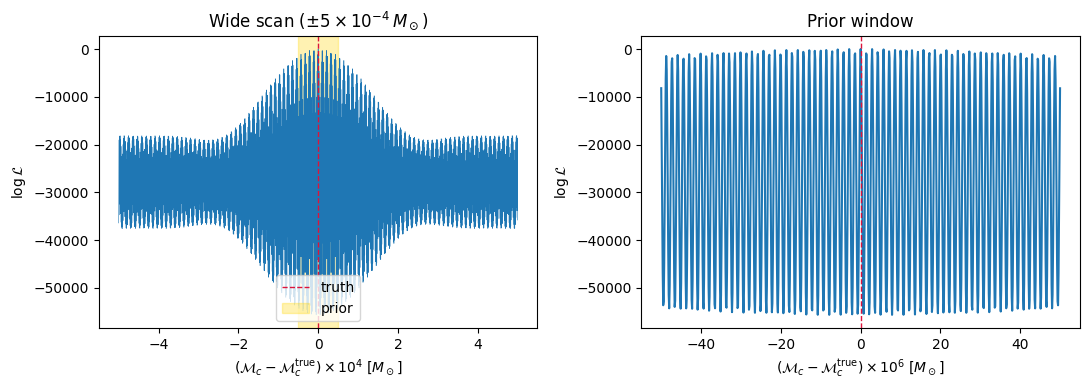

argmax Mc (prior) = 24.9976955008
truth   Mc        = 24.9976955008
max log L         = -3.638e-12  (should be ~0)


In [11]:
def Mc_logL_slice(Mc_grid):
    """logL on a 1-D Mc grid, all other params pinned at truth (one batched call)."""
    truth_batch = np.concatenate([
        parameters_to_live_point(
            [Mc if name == "Mc" else true_vals[name] for name in pe_model.names],
            pe_model.names,
        ) for Mc in Mc_grid
    ])
    return pe_model.log_likelihood(truth_batch)


Mc_wide  = np.linspace(true_Mc - 5.0e-4, true_Mc + 5.0e-4, 2001)
Mc_prior = np.linspace(*prior_bounds["Mc"], 801)

ll_wide  = Mc_logL_slice(Mc_wide)
ll_prior = Mc_logL_slice(Mc_prior)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot((Mc_wide - true_Mc) * 1e4, ll_wide, lw=0.4)
axes[0].axvline(0, color="crimson", ls="--", lw=1, label="truth")
axes[0].axvspan(
    (prior_bounds["Mc"][0] - true_Mc) * 1e4,
    (prior_bounds["Mc"][1] - true_Mc) * 1e4,
    color="gold", alpha=0.3, label="prior",
)
axes[0].set_xlabel(r"$(\mathcal{M}_c - \mathcal{M}_c^{\rm true}) \times 10^4$ [$M_\odot$]")
axes[0].set_ylabel(r"$\log\mathcal{L}$")
axes[0].set_title(r"Wide scan ($\pm 5\times 10^{-4}\,M_\odot$)")
axes[0].legend(loc="lower center")

axes[1].plot((Mc_prior - true_Mc) * 1e6, ll_prior)
axes[1].axvline(0, color="crimson", ls="--", lw=1)
axes[1].set_xlabel(r"$(\mathcal{M}_c - \mathcal{M}_c^{\rm true}) \times 10^6$ [$M_\odot$]")
axes[1].set_ylabel(r"$\log\mathcal{L}$")
axes[1].set_title("Prior window")

plt.tight_layout()
plt.show()

i_pk = int(np.argmax(ll_prior))
print(f"argmax Mc (prior) = {Mc_prior[i_pk]:.10f}")
print(f"truth   Mc        = {true_Mc:.10f}")
print(f"max log L         = {ll_prior[i_pk]:.3e}  (should be ~0)")

## 9. Run nessai

Progress is mirrored to `./pe_run_t3/nessai.log` -- tail that file from another shell to watch the sampler in real time.

In [12]:
output_dir = "./pe_run_t3"
if os.path.isdir(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

configure_logger(output=output_dir, label="nessai", log_level="INFO")

sampler = FlowSampler(
    pe_model,
    output=output_dir,
    nlive=250,
    seed=1234,
    resume=False,
    plot=True,
)
sampler.run()

05-21 13:33 nessai INFO    : Running Nessai version 0.15.2
05-21 13:33 nessai INFO    : pool and n_pool are none, no multiprocessing pool
05-21 13:33 nessai INFO    : Initialising nested sampler
05-21 13:33 nessai WARNING : Multiprocessing pool has already been configured.
/Users/diganta/Desktop/Papers/GWTF_cleanup_and_release/venv/lib/python3.12/site-packages/nessai/gw/__init__.py:12: FutureWarning: The `nessai.gw` module will be deprecated in the next release in favour of the nessai-gw package. This packages provides the same functionality as`nessai.gw` via the plugin interface.For more details, see: https://github.com/mj-will/nessai-gw
  warnings.warn(
05-21 13:33 nessai INFO    : Passing kwargs to FlowProposal: {'poolsize': 250}
05-21 13:33 nessai INFO    : No reparameterisations provided, using default reparameterisations included in FlowProposal
05-21 13:33 nessai INFO    : Adding reparameterisations from: {}
05-21 13:33 nessai INFO    : Assuming fallback reparameterisation (Scal

## 10. Posterior

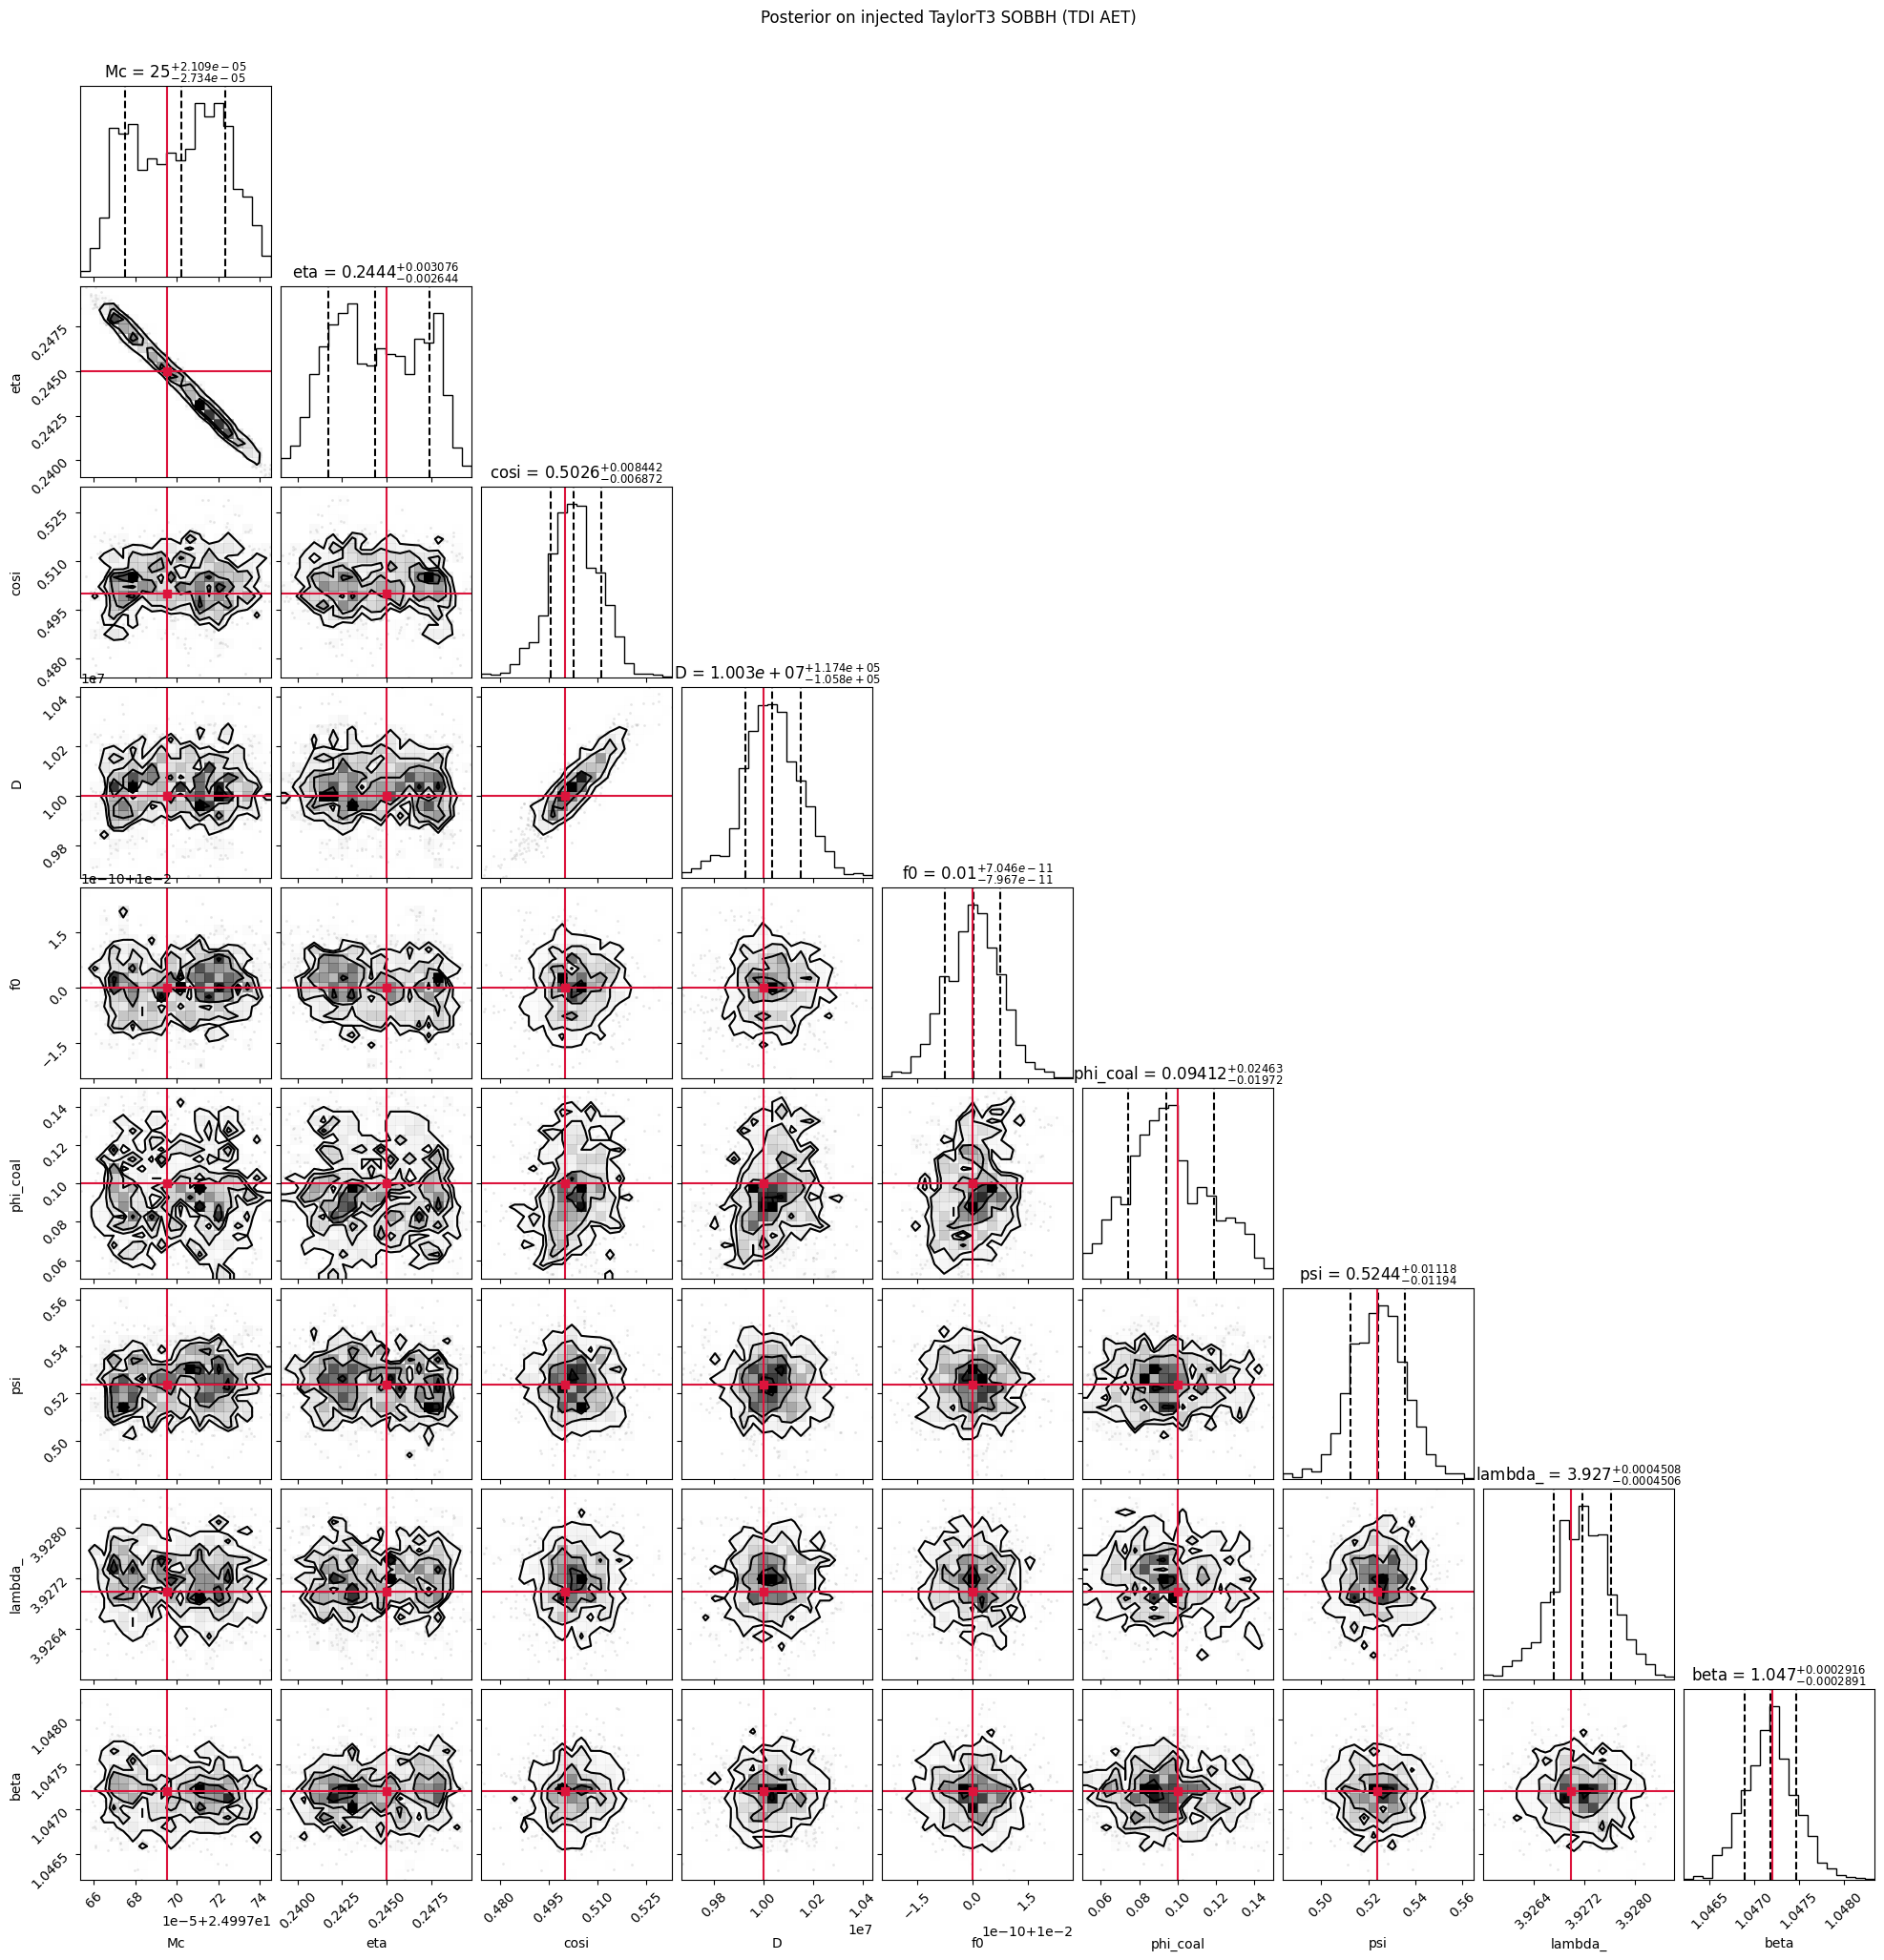

In [13]:
post = sampler.posterior_samples
samples = np.column_stack([post[n] for n in pe_model.names])
truths = [true_vals[n] for n in pe_model.names]

fig = corner.corner(
    samples,
    labels=pe_model.names,
    truths=truths,
    truth_color="crimson",
    show_titles=True,
    title_fmt=".4g",
    quantiles=[0.16, 0.5, 0.84],
)
fig.suptitle("Posterior on injected TaylorT3 SOBBH (TDI AET)", y=1.02)
plt.show()

# Benchmarking
The PE within this notebook has been benchmarked on both CPU and GPU, using the ``use_GPU`` flag at the top of the notebook. With the exact same settings, the total likelihood evaluation time on a CPU was <b>1 hour and 18 minutes</b>, on a GPU this was <b>3 minutes and 38 seconds</b>. This is completely expected as in the underlying code, for the 'batching', the CPU code loops through each of the sources in the batch, the GPU code instead assigns a individual GPU-thread to each source. 

Hardware: CPU: M4 Pro </br>
GPU: NVIDIA A100